In [89]:
library(tidyverse)
library(dplyr)
library(cowplot)
library("RColorBrewer")
library(ggplot2)
library(BSDA)

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

In [90]:
# Read file
fp_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/tp1_nulliparous/2025-11-10_fp_tp1_filt_nulliparous.csv", header = TRUE)
sp_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/tp1_nulliparous/2025-11-10_sp_tp1_filt_nulliparous.csv", header = TRUE)
combined_fp_sp <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/tp1_nulliparous/2025-11-11_combined_tp1_filt_nulliparous.csv", header = TRUE)

In [91]:
combined_fp_sp$Group

[1] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [5] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [9] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[13] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[17] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[21] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[25] "First pregnancy " "First pregnancy " "Second pregnancy" "Second pregnancy"
[29] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[33] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[37] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[41] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[45] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[49] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"

In [92]:
head(fp_tp1)
dim(fp_tp1)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,diffdays,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<int>,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>,<int>
1,5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,⋯,0,NA,NA,NA,NA,41,Spontaneous,NA,NA,0
2,5301,S1f862a6,NA,0,0,0,2018-03-07,P1f862a6,0,32,⋯,0,NA,NA,NA,NA,31,Spontaneous,very_w28_31,1,0
3,5258,S1f95844,NA,0,0,0,2018-04-10,P1f95844,0,30,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0
4,5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,⋯,0,NA,NA,NA,NA,39,Spontaneous,NA,NA,0
5,5243,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,⋯,0,NA,NA,NA,NA,41,Spontaneous,NA,NA,0
6,5383,S7e4a963,NA,0,0,0,2018-02-18,P424fd61,0,37,⋯,0,NA,NA,NA,NA,38,Induction,NA,NA,0


[1]  26 566

In [93]:
head(sp_tp1)
dim(sp_tp1)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,diffdays,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<int>,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<lgl>,<lgl>,<int>
1,5391,S159f9c8,NA,0,0,0,2021-01-28,P159f9c8,0,38,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0
2,5305,Sa79a719,NA,0,0,1,2019-01-17,P1f862a6,0,32,⋯,0,NA,NA,NA,NA,41,Induction,NA,NA,0
3,5309,S0e78496,NA,0,0,0,2020-12-17,P1f95844,0,33,⋯,0,NA,NA,NA,NA,39,Spontaneous,NA,NA,0
4,5311,S3cac7b0,NA,0,0,0,2020-10-20,P3cac7b0,0,33,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0
5,5252,S3db7da6,NA,0,0,1,2019-09-24,P3db7da6,0,30,⋯,0,NA,NA,NA,NA,39,Spontaneous,NA,NA,0
6,5415,S424fd61,NA,0,0,0,2020-11-03,P424fd61,0,40,⋯,31,NA,NA,NA,NA,38,Spontaneous,NA,NA,0


[1]  26 566

In [94]:
head(combined_fp_sp)
dim(combined_fp_sp)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>,<int>,<chr>
1,5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
2,5301,S1f862a6,NA,0,0,0,2018-03-07,P1f862a6,0,32,⋯,NA,NA,NA,NA,31,Spontaneous,very_w28_31,1,0,First pregnancy
3,5258,S1f95844,NA,0,0,0,2018-04-10,P1f95844,0,30,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,First pregnancy
4,5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,First pregnancy
5,5243,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
6,5383,S7e4a963,NA,0,0,0,2018-02-18,P424fd61,0,37,⋯,NA,NA,NA,NA,38,Induction,NA,NA,0,First pregnancy


[1]  52 567

# Quantitative =========================================================================================================

## Continuous ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

### Age -----------------------------------------------------------------------------------------------------------------------

In [95]:
dye <- c("First pregnancy " = "#F0E442", "Second pregnancy" = "#56B4E9")
combined_fp_sp$Group

[1] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [5] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [9] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[13] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[17] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[21] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[25] "First pregnancy " "First pregnancy " "Second pregnancy" "Second pregnancy"
[29] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[33] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[37] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[41] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[45] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[49] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"

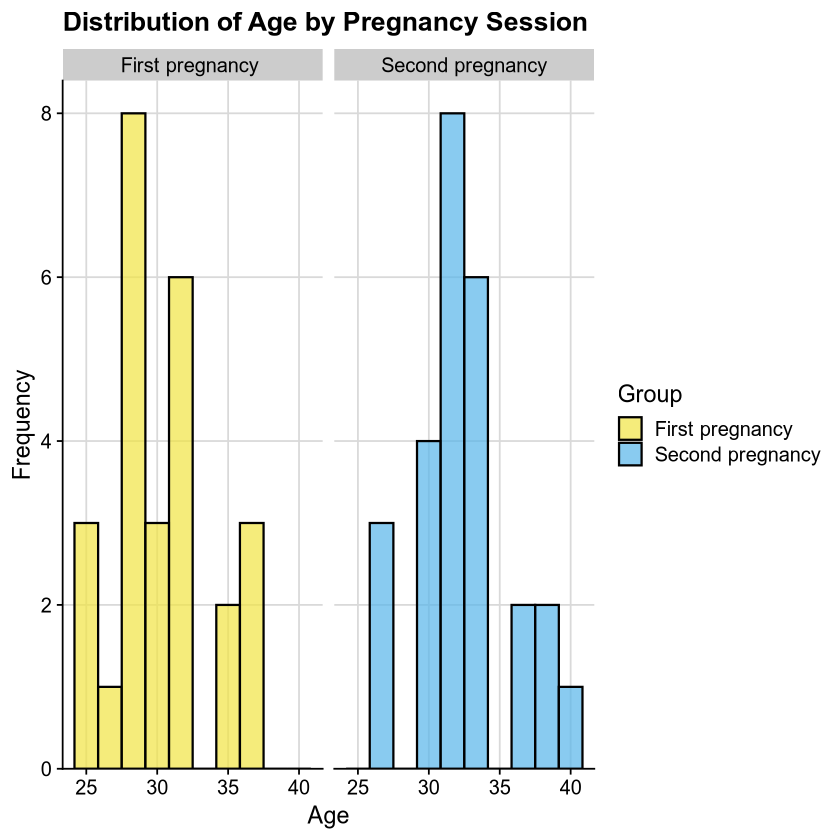

In [96]:
# Histogram of age distribution, grouped by pregnancy session (First vs Second)
age_histogram_combined <- combined_fp_sp |>
  ggplot(aes(x = age_checked, fill = Group)) +
  geom_histogram(bins = 10, col="black", alpha = 0.7, na.rm = TRUE)+
  facet_wrap(~ Group) + # Create one histogram per group 
  labs(
    x = "Age",
    y ="Frequency",
    title ="Distribution of Age by Pregnancy Session"
  ) +
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +    
    scale_fill_manual(values = dye) 
age_histogram_combined + theme_half_open() +
  background_grid()

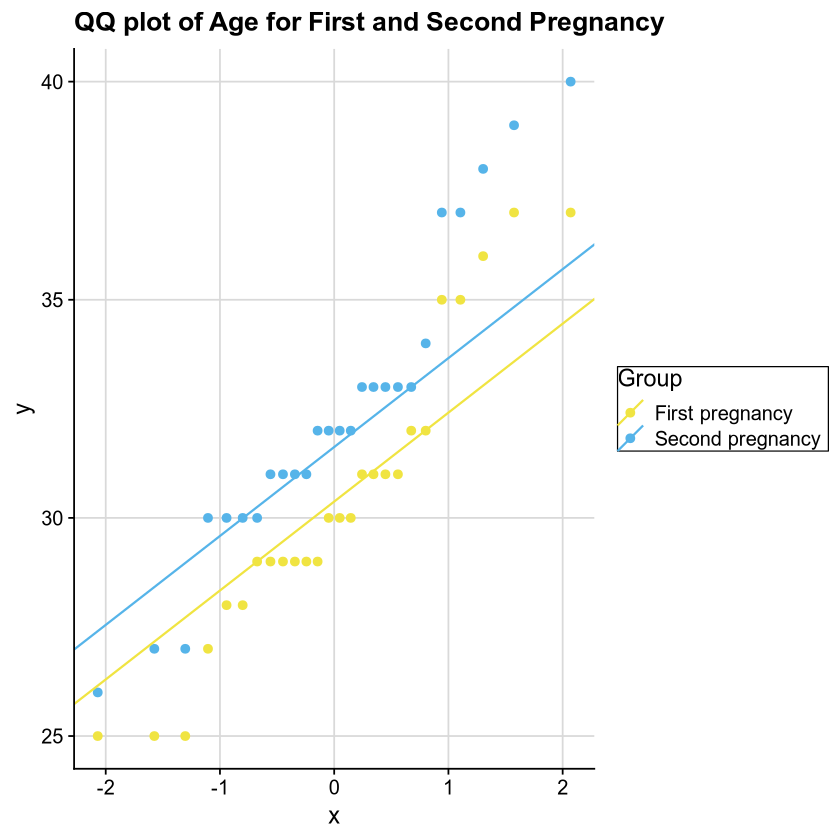

In [97]:
# QQ plot
age_qq_plot <- combined_fp_sp |>
  ggplot(aes(sample = age_checked, color = Group))+
  stat_qq() + 
  stat_qq_line() +
  labs(
    title = "QQ plot of Age for First and Second Pregnancy"
  ) +
  scale_colour_manual(values = dye)  +
  theme_half_open() +
  background_grid() +
  theme(
    legend.box.background = element_rect(color = "black")
  )
age_qq_plot
#display.brewer.all()

In [98]:
# Shapiro test
# In agreement with histogram --> normaly distributed
shapiro_first <- shapiro.test(fp_tp1$age_checked)
shapiro_first


	Shapiro-Wilk normality test

data:  fp_tp1$age_checked
W = 0.92967, p-value = 0.07611


In [99]:
shapiro_second <- shapiro.test(sp_tp1$age_checked)
shapiro_second


	Shapiro-Wilk normality test

data:  sp_tp1$age_checked
W = 0.93756, p-value = 0.1175


In [100]:
t_test_age <- t.test(
  combined_fp_sp$age_checked[combined_fp_sp$Group == "First pregnancy "],
  combined_fp_sp$age_checked[combined_fp_sp$Group == "Second pregnancy"],
  paired = TRUE
)
t_test_age


	Paired t-test

data:  combined_fp_sp$age_checked[combined_fp_sp$Group == "First pregnancy "] and combined_fp_sp$age_checked[combined_fp_sp$Group == "Second pregnancy"]
t = -16.125, df = 25, p-value = 1.013e-14
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -2.255454 -1.744546
sample estimates:
mean difference 
             -2 


### BMI --------------------------------------------------------------------------------------------------------------------------------------------------------------

In [101]:
# BMI (numerical)
combined_fp_sp$BMI_prior

[1] 21 25 22 21 21 24 21 28 19 21 20 16 24 27 29 22 23 23 19 24 23 29 23 23 23
[26] 23 25 25 21 22 23 23 23 29 19 20 21 17 33 26 29 24 28 23 19 26 23 30 23 23
[51] 21 23

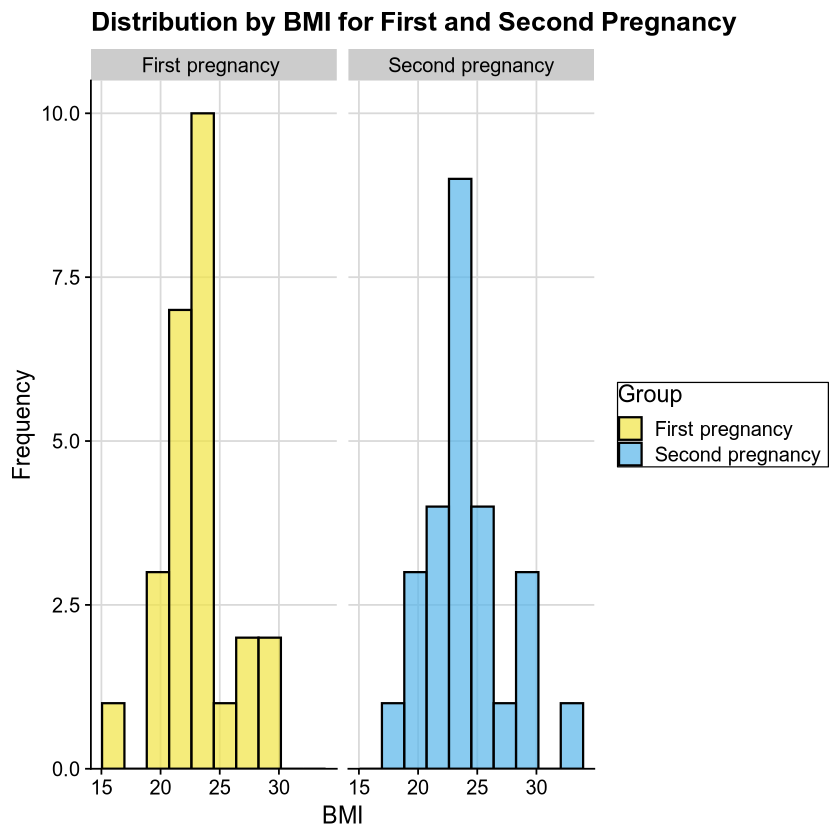

In [102]:
bmi_histogram_combined <- combined_fp_sp |>
  ggplot(aes(x = BMI_prior, fill =Group)) +
  geom_histogram(bins = 10, col = "black", alpha = 0.7, na.rm = TRUE) +
  facet_wrap(~ Group) +
  labs(
    x = "BMI",
    y = "Frequency",
    title = "Distribution by BMI for First and Second Pregnancy"
  ) +
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
    scale_fill_manual(values = dye) +
  theme_half_open() +
  background_grid() +
  theme(
    legend.box.background = element_rect(color = "black")
  )
bmi_histogram_combined

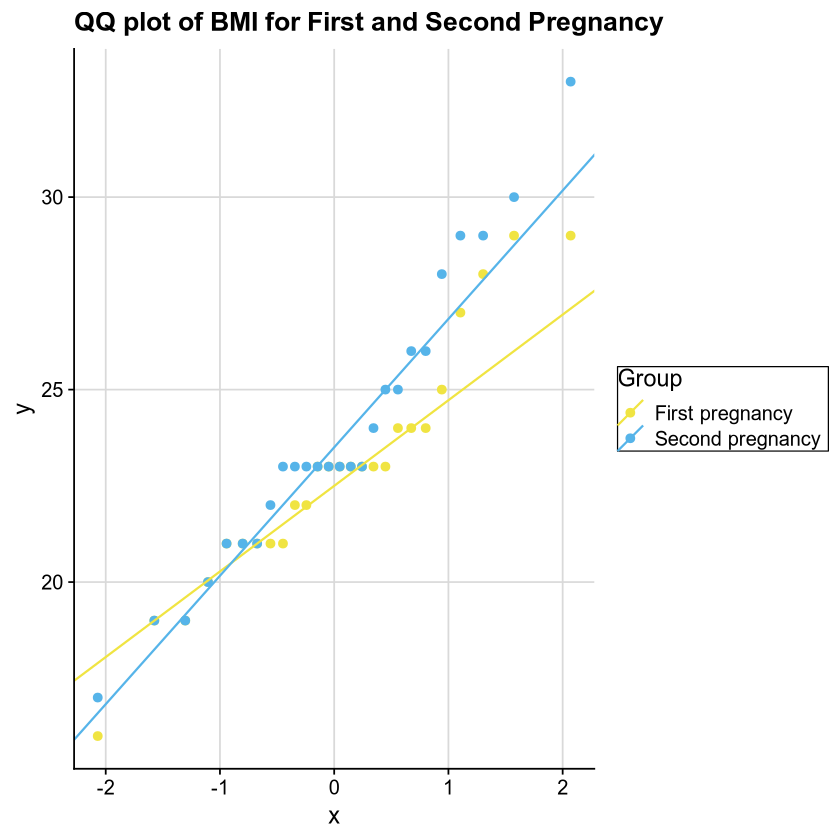

In [103]:
# bmi QQ plot
bmi_qq_plot <- combined_fp_sp |>
  ggplot(aes(sample = BMI_prior, color = Group)) +
  stat_qq() + 
  stat_qq_line() +
  labs (
    title = "QQ plot of BMI for First and Second Pregnancy"
  ) +
  scale_colour_manual(values = dye) +
  theme_half_open() +
  background_grid() +
  theme(
    legend.box.background = element_rect(color = "black")
  )
bmi_qq_plot
  

In [104]:
# Shapiro test
shapiro_first_bmi <- shapiro.test(fp_tp1$BMI_prior)
shapiro_first_bmi


	Shapiro-Wilk normality test

data:  fp_tp1$BMI_prior
W = 0.94357, p-value = 0.1634


In [105]:
shapiro_second_bmi <- shapiro.test(sp_tp1$BMI_prior)
shapiro_second_bmi


	Shapiro-Wilk normality test

data:  sp_tp1$BMI_prior
W = 0.95318, p-value = 0.275


In [106]:
# Since parametric --> t-test
combined_fp_sp_sorted <- combined_fp_sp[ order(combined_fp_sp$Q1_Personnummer, combined_fp_sp$Group), ]

fp_data_bmi <- combined_fp_sp_sorted$BMI_prior[combined_fp_sp_sorted$Group == "First pregnancy "]
sp_data_bmi <- combined_fp_sp_sorted$BMI_prior[combined_fp_sp_sorted$Group == "Second pregnancy"]
t.test(fp_data_bmi, sp_data_bmi, paired = TRUE)


	Paired t-test

data:  fp_data_bmi and sp_data_bmi
t = -2.1756, df = 25, p-value = 0.03924
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -1.87176467 -0.05131225
sample estimates:
mean difference 
     -0.9615385 


In [107]:
t_test_BMI <- t.test(
  combined_fp_sp$BMI_prior[combined_fp_sp$Group == "First pregnancy "],
  combined_fp_sp$BMI_prior[combined_fp_sp$Group == "Second pregnancy"],
  paired = TRUE
)
t_test_BMI


	Paired t-test

data:  combined_fp_sp$BMI_prior[combined_fp_sp$Group == "First pregnancy "] and combined_fp_sp$BMI_prior[combined_fp_sp$Group == "Second pregnancy"]
t = -2.1756, df = 25, p-value = 0.03924
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -1.87176467 -0.05131225
sample estimates:
mean difference 
     -0.9615385 


# Categorical ===============================================================================

## Nominal data ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

### Excess weight ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [108]:
class(fp_tp1$excess_weight)
class(sp_tp1$excess_weight)

[1] "character"

[1] "character"

In [109]:
# Convert to factor
fp_tp1 <- fp_tp1 |>
  mutate(excess_weight = as.factor(ifelse(fp_tp1$excess_weight == "NA", NA, ifelse(excess_weight =="No", 0, 1)))) 
sp_tp1 <- sp_tp1 |>
  mutate(excess_weight = as.factor(ifelse(sp_tp1$excess_weight == "NA", NA, ifelse(excess_weight =="No", 0, 1)))) 

In [110]:
# Select variables of interest
fp_excess_weight <- fp_tp1 |>
  select(Q1_Personnummer, excess_weight)
sp_excess_weight <- sp_tp1 |>
  select(Q1_Personnummer, excess_weight)

In [111]:
combined_df_excess_weight <-  merge(fp_excess_weight, sp_excess_weight, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
dim(combined_df_excess_weight)

[1] 26  3

In [112]:
combined_df_excess_weight |> filter(is.na(combined_df_excess_weight$excess_weight_FP))
combined_df_excess_weight |> filter(is.na(combined_df_excess_weight$excess_weight_SP))

Q1_Personnummer,excess_weight_FP,excess_weight_SP
<chr>,<fct>,<fct>
Pbe289c8,NA,0


Q1_Personnummer,excess_weight_FP,excess_weight_SP
<chr>,<fct>,<fct>
Pe706703,0,NA


In [25]:
# Contingency table
tab_excess_weight <- table(combined_df_excess_weight$excess_weight_FP, combined_df_excess_weight$excess_weight_SP)
tab_excess_weight

   
    0 1
  0 9 7
  1 1 7

In [26]:
# Non-parametric paired categorical data --> use McNemar's test
mcnemar.test(tab_excess_weight)


	McNemar's Chi-squared test with continuity correction

data:  tab_excess_weight
McNemar's chi-squared = 3.125, df = 1, p-value = 0.0771


In [ ]:
# Since  missing values come from differen participants, use Method D

In [114]:
# Select variables of interest
fp_excess_weight <- fp_tp1 |>
  select(Q1_Personnummer, excess_weight)
sp_excess_weight <- sp_tp1 |>
  select(Q1_Personnummer, excess_weight)

In [117]:
# Combine both df so each personal# has two values
combined_df_weight <- merge(fp_excess_weight, sp_excess_weight, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_weight |> head()

,Q1_Personnummer,excess_weight_FP,excess_weight_SP
,<chr>,<fct>,<fct>
1,P159f9c8,1,0
2,P1f862a6,1,1
3,P1f95844,0,0
4,P3cac7b0,0,1
5,P3db7da6,0,1
6,P424fd61,0,0


In [119]:
# NA ONLY for fp
missing_pn_weight_fp <- combined_df_weight|> filter(is.na(combined_df_weight$excess_weight_FP) & !is.na(combined_df_weight$excess_weight_SP)) |> 
  pull(Q1_Personnummer)
missing_pn_weight_fp

[1] "Pbe289c8"

In [120]:
# NA ONLY for sp
missing_pn_weight_sp <- combined_df_weight|> filter(is.na(combined_df_weight$excess_weight_SP) & !is.na(combined_df_weight$excess_weight_FP)) |> 
  pull(Q1_Personnummer)
missing_pn_weight_sp

[1] "Pe706703"

In [121]:
# Pull personal# where NA for BOTH fp AND sp
missing_pn_weight_both  <- combined_df_weight |> 
    filter(is.na(combined_df_weight$excess_weight_FP) & is.na(combined_df_weight$excess_weight_SP)) |> 
  pull(Q1_Personnummer)
missing_pn_weight_both
length(missing_pn_weight_both) # no pn are missing for both

character(0)

[1] 0

In [122]:
# P-value
# Make sure stress_FP and stress_SP are numeric (NOT factors)
combined_df_weight$excess_weight_FP <- as.numeric(as.character(combined_df_weight$excess_weight_FP))
combined_df_weight$excess_weight_SP <- as.numeric(as.character(combined_df_weight$excess_weight_SP))

In [123]:
# 2. Split into groups
m2 <- combined_df_weight[!is.na(combined_df_weight$excess_weight_SP) & !is.na(combined_df_weight$excess_weight_FP), ] # complete
m1 <- combined_df_weight[!is.na(combined_df_weight$excess_weight_FP) & is.na(combined_df_weight$excess_weight_SP), ]  # only FP 
m3 <- combined_df_weight[is.na(combined_df_weight$excess_weight_FP) & !is.na(combined_df_weight$excess_weight_SP), ]  # only SP

In [124]:
m2 |> dim()
m1 |> dim() # NA for sp
m3 |> dim() # NA for fp

[1] 24  3

[1] 1 3

[1] 1 3

In [125]:
# 3. Sizes
n_total <- nrow(combined_df_weight)
m1_n <- nrow(m1)
m2_n <- nrow(m2)
m3_n <- nrow(m3)

Pms <- m1_n / n_total # missing depression SP
Pmt <- m3_n / n_total # missing depression SP
Pms

[1] 0.03846154

In [126]:
# 4. Paired estimator Δ̂(P)
delta_paired <- mean(m2$excess_weight_SP - m2$excess_weight_FP, na.rm = TRUE)
delta_paired

[1] 0.25

In [134]:
# 5. Unpaired estimator Δ̂(U)
P_s <- mean(m1$excess_weight_FP, na.rm = TRUE) # from m1
P_t <- mean(m3$excess_weight_SP, na.rm = TRUE) # from m3
delta_unpaired <- P_t - P_s
delta_unpaired
P_t
P_s

[1] 0

[1] 0

[1] 0

In [128]:
# 6. Calculate components for V_P
P01 <- sum(m2$excess_weight_FP == 0 & m2$excess_weight_SP == 1) / m2_n
P10 <- sum(m2$excess_weight_FP == 1 & m2$excess_weight_SP == 0) / m2_n
P01
P10


VP <- (P01 + P10 - (P01 - P10)^2) / (1 - Pms - Pmt)
VP

[1] 0.2916667

[1] 0.04166667

[1] 0.2934028

In [129]:
# 7. Calculate VU
VU <- (P_s * (1 - P_s)) / Pms + (P_t * (1 - P_t)) / Pmt
VU

[1] 0

In [130]:
# 8. Weight w and hybrid estimator
w <- VU / (VU + VP)
delta_D <- w * delta_unpaired + (1 - w) * delta_paired

In [131]:
# 9. Combined variance and SE
var_D <- (VU * VP) / (VU + VP)
se_D <- sqrt(var_D)

In [132]:
# 10. Z-test
z_value <- delta_D / se_D
p_value <- 2 * (1 - pnorm(abs(z_value)))
print(p_value)

[1] 0


### Gestational Diabetes --------------------------------------------------------------------------------------------------------------------------------------------------------------

In [27]:
class(fp_tp1$Q1_X73.1_Pregnancy_problems_gestational_diabetes)
class(sp_tp1$Q1_X73.1_Pregnancy_problems_gestational_diabetes)

[1] "character"

[1] "character"

In [28]:
combined_fp_sp$Q1_X73.1_Pregnancy_problems_gestational_diabetes

[1] "Nej" NA    NA    "Nej" NA    NA    "Nej" NA    NA    NA    NA    NA   
[13] NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA   
[25] NA    NA    NA    NA    NA    "Nej" NA    NA    NA    NA    NA    NA   
[37] NA    "Nej" NA    NA    NA    NA    NA    NA    NA    NA    NA    "Nej"
[49] NA    NA    NA    NA

In [29]:
fp_tp1 <- fp_tp1 |>
  mutate(Q1_X73.1_Pregnancy_problems_gestational_diabetes = as.factor(ifelse(fp_tp1$Q1_X73.1_Pregnancy_problems_gestational_diabetes == "Nej", 0, 1)))
sp_tp1 <- sp_tp1 |>
  mutate(Q1_X73.1_Pregnancy_problems_gestational_diabetes = as.factor(ifelse(sp_tp1$Q1_X73.1_Pregnancy_problems_gestational_diabetes == "Nej", 0, 1)))

In [30]:
fp_tp1$Q1_X73.1_Pregnancy_problems_gestational_diabetes
sp_tp1$Q1_X73.1_Pregnancy_problems_gestational_diabetes

[1] 0    <NA> <NA> 0    <NA> <NA> 0    <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA>
[16] <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA>
Levels: 0

[1] <NA> <NA> <NA> 0    <NA> <NA> <NA> <NA> <NA> <NA> <NA> 0    <NA> <NA> <NA>
[16] <NA> <NA> <NA> <NA> <NA> <NA> 0    <NA> <NA> <NA> <NA>
Levels: 0

In [31]:
fp_diabetes <- fp_tp1 |>
  select(Q1_Personnummer, Q1_X73.1_Pregnancy_problems_gestational_diabetes)
sp_diabetes <- sp_tp1 |>
  select(Q1_Personnummer, Q1_X73.1_Pregnancy_problems_gestational_diabetes)

In [32]:
combined_df_diabetes <- merge(fp_diabetes, sp_diabetes, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_diabetes
dim(combined_df_diabetes)

Q1_Personnummer,Q1_X73.1_Pregnancy_problems_gestational_diabetes_FP,Q1_X73.1_Pregnancy_problems_gestational_diabetes_SP
<chr>,<fct>,<fct>
P159f9c8,0,NA
P1f862a6,NA,NA
P1f95844,NA,NA
P3cac7b0,0,0
P3db7da6,NA,NA
P424fd61,NA,NA
P42f2c08,0,NA
P4de45e7,NA,NA
P50f102c,NA,NA


[1] 26  3

In [33]:
tab_diabetes <- table(
  factor(combined_df_diabetes$Q1_X73.1_Pregnancy_problems_gestational_diabetes_FP, levels = c(0, 1)),
  factor(combined_df_diabetes$Q1_X73.1_Pregnancy_problems_gestational_diabetes_SP, levels = c(0, 1))
)

In [34]:
tab_diabetes 
mcnemar.test(tab_diabetes)

   
    0 1
  0 1 0
  1 0 0


	McNemar's Chi-squared test

data:  tab_diabetes
McNemar's chi-squared = NaN, df = 1, p-value = NA


### Depression--------------------------------------------------------------------------------------------------------------------------------------------------------------

In [35]:
class(combined_fp_sp$Depression_score_sum_Q1)

[1] "integer"

In [36]:
# Convert to categories
depression_category_fp <- ifelse(fp_tp1$Depression_score_sum_Q1 >= 0 & fp_tp1$Depression_score_sum_Q1 < 13, 0, 
                                 ifelse(fp_tp1$Depression_score_sum_Q1 >= 13 & fp_tp1$Depression_score_sum_Q1 <= 30, 1, NA))
depression_category_fp

depression_category_sp <- ifelse(sp_tp1$Depression_score_sum_Q1 >= 0 & sp_tp1$Depression_score_sum_Q1 < 13,  0, 
                                 ifelse(sp_tp1$Depression_score_sum_Q1 >= 13 & sp_tp1$Depression_score_sum_Q1 <= 30, 1, NA))
depression_category_sp

[1]  0  0 NA NA  0  0  0  0  0  0  0  0  0  1  0  0  0 NA  0  0  0  0  1  0  0
[26]  0

[1]  0  0  0  1  1  0  0  0  0 NA  0  0  0  0  1  0  1  0  0  1  0  0  0  0  0
[26]  0

In [37]:
# Add depression category column
fp_tp1$Q1_Depression_category <- as.factor(depression_category_fp)
sp_tp1$Q1_Depression_category <- as.factor(depression_category_sp)
class(fp_tp1$Q1_Depression_category)

[1] "factor"

In [38]:
fp_depression <- fp_tp1 |>
  select(Q1_Personnummer, Q1_Depression_category)
sp_depression <- sp_tp1 |>
  select(Q1_Personnummer, Q1_Depression_category)

In [39]:
combined_df_depression <- merge(fp_depression, sp_depression, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_depression
dim(combined_df_depression)

Q1_Personnummer,Q1_Depression_category_FP,Q1_Depression_category_SP
<chr>,<fct>,<fct>
P159f9c8,0,0
P1f862a6,0,0
P1f95844,NA,0
P3cac7b0,NA,1
P3db7da6,0,1
P424fd61,0,0
P42f2c08,0,0
P4de45e7,0,0
P50f102c,0,0


[1] 26  3

In [40]:
tab_depression <- table(combined_df_depression$Q1_Depression_category_FP, combined_df_depression$Q1_Depression_category_SP)
tab_depression

   
     0  1
  0 16  4
  1  2  0

In [41]:
mcnemar.test(tab_depression)


	McNemar's Chi-squared test with continuity correction

data:  tab_depression
McNemar's chi-squared = 0.16667, df = 1, p-value = 0.6831


### Stress--------------------------------------------------------------------------------------------------------------------------------------------------------------

In [42]:
class(combined_fp_sp$high_stress_Q1)

[1] "integer"

In [43]:
fp_tp1$high_stress_Q1 <- as.factor(fp_tp1$high_stress_Q1 )
sp_tp1$high_stress_Q1 <- as.factor(sp_tp1$high_stress_Q1 )
class(fp_tp1$high_stress_Q1)
class(sp_tp1$high_stress_Q1)

[1] "factor"

[1] "factor"

In [44]:
fp_stress <- fp_tp1 |>
  select(Q1_Personnummer, high_stress_Q1)
sp_stress <- sp_tp1 |>
  select(Q1_Personnummer, high_stress_Q1)
head(sp_stress)

,Q1_Personnummer,high_stress_Q1
,<chr>,<fct>
1,P159f9c8,1
2,P1f862a6,0
3,P1f95844,1
4,P3cac7b0,1
5,P3db7da6,1
6,P424fd61,0


In [45]:
combined_df_stress <- merge(fp_stress, sp_stress, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
head(combined_df_stress)

,Q1_Personnummer,high_stress_Q1_FP,high_stress_Q1_SP
,<chr>,<fct>,<fct>
1,P159f9c8,0,1
2,P1f862a6,0,0
3,P1f95844,1,1
4,P3cac7b0,1,1
5,P3db7da6,0,1
6,P424fd61,0,0


In [46]:
tab_stress <- table(combined_df_stress$high_stress_Q1_FP, combined_df_stress$high_stress_Q1_SP)

In [47]:
mcnemar.test(tab_stress)


	McNemar's Chi-squared test with continuity correction

data:  tab_stress
McNemar's chi-squared = 4, df = 1, p-value = 0.0455


### Smoking --------------------------------------------------------------------------------------------------------------------------------------------------------------

In [48]:
# Convert Q1_Smoking_ to categories checked
smoking_category_fp <- ifelse(fp_tp1$Q1_Smoking_checked == "Nej, jag har aldrig rökt", 0, 
                           ifelse(fp_tp1$Q1_Smoking_checked == "Rökt tidigare", 0,
                                  ifelse(fp_tp1$Q1_Smoking_checked == "Feströkare", 1, NA)))
table(smoking_category_fp)

smoking_category_fp
 0  1 
24  2 

In [49]:
smoking_category_sp <- ifelse(sp_tp1$Q1_Smoking_checked == "Nej, jag har aldrig rökt", 0, 
                              ifelse(sp_tp1$Q1_Smoking_checked == "Rökt tidigare", 0,
                                     ifelse(sp_tp1$Q1_Smoking_checked == "Feströkare", 1, NA)))
table(smoking_category_sp)

smoking_category_sp
 0  1 
25  1 

In [50]:
# Check for NA
sum(is.na(smoking_category_fp))
sum(is.na(smoking_category_sp))

[1] 0

[1] 0

In [51]:
# Create new column with smoking category
fp_tp1$smoking_category_Q1 <- smoking_category_fp
fp_tp1$smoking_category_Q1 

[1] 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0

In [52]:
sp_tp1$smoking_category_Q1 <- smoking_category_sp
sp_tp1$smoking_category_Q1

[1] 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [53]:
fp_smoking <- fp_tp1 |>
  select(Q1_Personnummer, smoking_category_Q1)
sp_smoking <- sp_tp1 |> 
  select(Q1_Personnummer, smoking_category_Q1)

In [54]:
combined_df_smoking <- merge(fp_smoking, sp_smoking, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
head(combined_df_smoking)
dim(combined_df_smoking)

,Q1_Personnummer,smoking_category_Q1_FP,smoking_category_Q1_SP
,<chr>,<dbl>,<dbl>
1,P159f9c8,0,0
2,P1f862a6,0,0
3,P1f95844,1,1
4,P3cac7b0,0,0
5,P3db7da6,0,0
6,P424fd61,0,0


[1] 26  3

In [55]:
table(combined_df_smoking)

, , smoking_category_Q1_SP = 0

               smoking_category_Q1_FP
Q1_Personnummer 0 1
       P159f9c8 1 0
       P1f862a6 1 0
       P1f95844 0 0
       P3cac7b0 1 0
       P3db7da6 1 0
       P424fd61 1 0
       P42f2c08 1 0
       P4de45e7 1 0
       P50f102c 1 0
       P5b98b6c 1 0
       P62ea0b2 1 0
       P719b21e 1 0
       P735d77f 1 0
       P7ece52e 1 0
       P92b4604 1 0
       P97574f9 0 1
       P9cdfd5a 1 0
       Pa8f3b51 1 0
       Pbe04f9f 1 0
       Pbe289c8 1 0
       Pc44e366 1 0
       Pc77a35c 1 0
       Pca94a0f 1 0
       Pdab1897 1 0
       Pe706703 1 0
       Pf573f67 1 0

, , smoking_category_Q1_SP = 1

               smoking_category_Q1_FP
Q1_Personnummer 0 1
       P159f9c8 0 0
       P1f862a6 0 0
       P1f95844 0 1
       P3cac7b0 0 0
       P3db7da6 0 0
       P424fd61 0 0
       P42f2c08 0 0
       P4de45e7 0 0
       P50f102c 0 0
       P5b98b6c 0 0
       P62ea0b2 0 0
       P719b21e 0 0
       P735d77f 0 0
       P7ece52e 0 0
       P92b4604 0 0

In [56]:
# To solve problem with error 
tab_smoking <- table(
  factor(combined_df_smoking$smoking_category_Q1_FP, levels = c(0, 1)), 
  factor(combined_df_smoking$smoking_category_Q1_SP, levels = c(0, 1))
  )

In [57]:
mcnemar.test(tab_smoking)


	McNemar's Chi-squared test with continuity correction

data:  tab_smoking
McNemar's chi-squared = 0, df = 1, p-value = 1


### Alcohol--------------------------------------------------------------------------------------------------------------------------------------------------------------

In [58]:
class(combined_fp_sp$Q1_X64_Alcohol_during_pregnancy)

[1] "integer"

In [59]:
fp_tp1$Q1_X64_Alcohol_during_pregnancy <- as.factor(fp_tp1$Q1_X64_Alcohol_during_pregnancy )
sp_tp1$Q1_X64_Alcohol_during_pregnancy <- as.factor(sp_tp1$Q1_X64_Alcohol_during_pregnancy )
class(fp_tp1$Q1_X64_Alcohol_during_pregnancy)
class(sp_tp1$Q1_X64_Alcohol_during_pregnancy)

[1] "factor"

[1] "factor"

In [60]:
fp_alcohol <- fp_tp1 %>%
  select(Q1_Personnummer, Q1_X64_Alcohol_during_pregnancy)
sp_alcohol <- sp_tp1  %>%
  select(Q1_Personnummer, Q1_X64_Alcohol_during_pregnancy)

In [61]:
combined_df_alcohol <- merge(fp_alcohol, sp_alcohol, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))

In [62]:
tab_alcohol <- table(
  factor(combined_df_alcohol$Q1_X64_Alcohol_during_pregnancy_FP, levels = c(0, 1)),
  factor(combined_df_alcohol$Q1_X64_Alcohol_during_pregnancy_SP, levels = c(0, 1))
)

In [63]:
tab_alcohol 

   
     0  1
  0 25  0
  1  1  0

In [64]:
mcnemar.test(tab_alcohol)


	McNemar's Chi-squared test with continuity correction

data:  tab_alcohol
McNemar's chi-squared = 0, df = 1, p-value = 1


### Antibiotic distribution--------------------------------------------------------------------------------------------------------------------------------------------------------------

In [65]:
class(combined_fp_sp$Q1_X43.Antibiotics_last_3_months)
table(combined_fp_sp$Q1_X43.Antibiotics_last_3_months)

[1] "integer"


 0  1 
51  1 

In [66]:
fp_tp1$Q1_X43.Antibiotics_last_3_months <- as.factor(fp_tp1$Q1_X43.Antibiotics_last_3_months )
sp_tp1$Q1_X43.Antibiotics_last_3_months <- as.factor(sp_tp1$Q1_X43.Antibiotics_last_3_months )
class(fp_tp1$Q1_X43.Antibiotics_last_3_months)
class(sp_tp1$Q1_X43.Antibiotics_last_3_months)

[1] "factor"

[1] "factor"

In [67]:
fp_anti <- fp_tp1 |> 
  select(Q1_Personnummer, Q1_X43.Antibiotics_last_3_months) 
sp_anti <- sp_tp1 |>
  select(Q1_Personnummer, Q1_X43.Antibiotics_last_3_months) 

In [68]:
combined_df_anti <- merge(fp_anti, sp_anti, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))

In [69]:
head(combined_df_anti)
dim(combined_df_anti)

,Q1_Personnummer,Q1_X43.Antibiotics_last_3_months_FP,Q1_X43.Antibiotics_last_3_months_SP
,<chr>,<fct>,<fct>
1,P159f9c8,0,0
2,P1f862a6,0,0
3,P1f95844,0,0
4,P3cac7b0,0,0
5,P3db7da6,0,0
6,P424fd61,0,0


[1] 26  3

In [72]:
# Create contingency table with two levels
tab_anti <- table(
  factor(combined_df_anti$Q1_X43.Antibiotics_last_3_months_FP, levels = c(0, 1)),
      factor(combined_df_anti$Q1_X43.Antibiotics_last_3_months_SP, levels = c(0, 1))
)
tab_anti

   
     0  1
  0 25  0
  1  1  0

In [73]:
# Non-parametric paired categorical data --> use McNemar's test
mcnemar.test(tab_anti)


	McNemar's Chi-squared test with continuity correction

data:  tab_anti
McNemar's chi-squared = 0, df = 1, p-value = 1


### Diet --------------------------------------------------------------------------------------------------------------------------------------------------------------

In [196]:
# combined$Q1_healthydiet --> yes if health score less than 3
class(combined_fp_sp$Q1_healthydiet)

[1] "integer"

In [197]:
fp_tp1$Q1_healthydiet <- as.factor(fp_tp1$Q1_healthydiet )
sp_tp1$Q1_healthydiet <- as.factor(sp_tp1$Q1_healthydiet )
class(fp_tp1$Q1_healthydiet)
class(sp_tp1$Q1_healthydiet)

[1] "factor"

[1] "factor"

In [198]:
fp_diet <- fp_tp1 |>
  select(Q1_Personnummer, Q1_healthydiet)
sp_diet <- sp_tp1 |>
  select(Q1_Personnummer, Q1_healthydiet)

In [199]:
combined_df_diet <- merge(fp_diet, sp_diet, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))

In [200]:
tab_diet <- table(combined_df_diet$Q1_healthydiet_FP, combined_df_diet$Q1_healthydiet_SP)
tab_diet

   
     0  1
  0  4  0
  1  6 16

In [201]:
mcnemar.test(tab_diet)


	McNemar's Chi-squared test with continuity correction

data:  tab_diet
McNemar's chi-squared = 4.1667, df = 1, p-value = 0.04123


### Daily fiber--------------------------------------------------------------------------------------------------------------------------------------------------------------

In [202]:
class(combined_fp_sp$Q1_dailyfiber)

[1] "integer"

In [203]:
fp_tp1$Q1_dailyfiber <- as.factor(fp_tp1$Q1_dailyfiber)
sp_tp1$Q1_dailyfiber <- as.factor(sp_tp1$Q1_dailyfiber)
class(fp_tp1$Q1_dailyfiber)
class(sp_tp1$Q1_dailyfiber)

[1] "factor"

[1] "factor"

In [204]:
fp_fiber <- fp_tp1 |>
  select(Q1_Personnummer, Q1_dailyfiber)
sp_fiber <- sp_tp1 |>
  select(Q1_Personnummer, Q1_dailyfiber)

In [205]:
combined_df_fiber <- merge(fp_fiber, sp_fiber, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))

In [206]:
tab_fiber <- table(combined_df_fiber$Q1_dailyfiber_FP, combined_df_fiber$Q1_dailyfiber_SP)

In [207]:
mcnemar.test(tab_fiber)


	McNemar's Chi-squared test with continuity correction

data:  tab_fiber
McNemar's chi-squared = 0.8, df = 1, p-value = 0.3711


###  PCOS--------------------------------------------------------------------------------------------------------------------------------------------------------------

In [208]:
class(combined_fp_sp$Q1_X31_Diagnosed_PCOS)

[1] "character"

In [209]:
fp_tp1 <- fp_tp1 |>
  mutate(Q1_X31_Diagnosed_PCOS = as.factor(ifelse(fp_tp1$Q1_X31_Diagnosed_PCOS == "Vet inte", NA, ifelse(fp_tp1$Q1_X31_Diagnosed_PCOS == "Nej", 0, 1))))
sp_tp1 <- sp_tp1 |>
  mutate(Q1_X31_Diagnosed_PCOS = as.factor(ifelse (sp_tp1$Q1_X31_Diagnosed_PCOS == "Vet inte", NA, ifelse(sp_tp1$Q1_X31_Diagnosed_PCOS == "Nej", 0, 1))))
class(fp_tp1$Q1_X31_Diagnosed_PCOS)
class(sp_tp1$Q1_X31_Diagnosed_PCOS)

[1] "factor"

[1] "factor"

In [210]:
fp_pcos <- fp_tp1 |>
  select(Q1_Personnummer, Q1_X31_Diagnosed_PCOS)
sp_pcos <- sp_tp1 |>
  select(Q1_Personnummer, Q1_X31_Diagnosed_PCOS)
 

In [211]:
combined_df_pcos <- merge(fp_pcos, sp_pcos, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))

In [212]:
tab_pcos <- table(combined_df_pcos$Q1_X31_Diagnosed_PCOS_FP, combined_df_pcos$Q1_X31_Diagnosed_PCOS_SP)

In [213]:
mcnemar.test(tab_pcos)


	McNemar's Chi-squared test with continuity correction

data:  tab_pcos
McNemar's chi-squared = 0, df = 1, p-value = 1


#  Catgorical===============================================================================

## Ordinal data~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~¨¨

### BMI ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [214]:
# Merge the two dataframes by personal numbers
fp_bmi <- fp_tp1 |>
  select(Q1_Personnummer, BMI_3_groups)
sp_bmi <- sp_tp1 |>
  select(Q1_Personnummer, BMI_3_groups)

In [215]:
bmi_merged <- merge(fp_bmi, sp_bmi, by = "Q1_Personnummer", suffixes = c("_fp", "_sp"))
head(bmi_merged)
dim(bmi_merged)

,Q1_Personnummer,BMI_3_groups_fp,BMI_3_groups_sp
,<chr>,<chr>,<chr>
1,P159f9c8,18.5-25 Normal weight,Missing
2,P1f862a6,Missing,Missing
3,P1f95844,18.5-25 Normal weight,18.5-25 Normal weight
4,P3cac7b0,18.5-25 Normal weight,18.5-25 Normal weight
5,P3db7da6,18.5-25 Normal weight,18.5-25 Normal weight
6,P424fd61,18.5-25 Normal weight,18.5-25 Normal weight


[1] 26  3

In [216]:
sum(is.na(bmi_merged))

[1] 0

In [217]:
# Wherever there is a missing value, replace it with NA
bmi_merged[bmi_merged == "Missing"] <- NA
sum(is.na(bmi_merged))

[1] 3

In [218]:
head(bmi_merged)
dim(bmi_merged)

,Q1_Personnummer,BMI_3_groups_fp,BMI_3_groups_sp
,<chr>,<chr>,<chr>
1,P159f9c8,18.5-25 Normal weight,NA
2,P1f862a6,NA,NA
3,P1f95844,18.5-25 Normal weight,18.5-25 Normal weight
4,P3cac7b0,18.5-25 Normal weight,18.5-25 Normal weight
5,P3db7da6,18.5-25 Normal weight,18.5-25 Normal weight
6,P424fd61,18.5-25 Normal weight,18.5-25 Normal weight


[1] 26  3

In [219]:
# Drop the missing values, because it will affect the results
bmi_merged_clean <- bmi_merged |>
  filter(!is.na(BMI_3_groups_sp) & !is.na(BMI_3_groups_fp))

In [220]:
head(bmi_merged_clean)
dim(bmi_merged_clean)
sum(is.na(bmi_merged_clean))

,Q1_Personnummer,BMI_3_groups_fp,BMI_3_groups_sp
,<chr>,<chr>,<chr>
1,P1f95844,18.5-25 Normal weight,18.5-25 Normal weight
2,P3cac7b0,18.5-25 Normal weight,18.5-25 Normal weight
3,P3db7da6,18.5-25 Normal weight,18.5-25 Normal weight
4,P424fd61,18.5-25 Normal weight,18.5-25 Normal weight
5,P42f2c08,18.5-25 Normal weight,18.5-25 Normal weight
6,P4de45e7,> 25 Overweight,> 25 Overweight


[1] 24  3

[1] 0

In [221]:
table(bmi_merged_clean$BMI_3_groups_fp)
table(bmi_merged_clean$BMI_3_groups_sp)


   < 18.5 Underweight       > 25 Overweight 18.5-25 Normal weight 
                    1                     4                    19 


   < 18.5 Underweight       > 25 Overweight 18.5-25 Normal weight 
                    1                     7                    16 

In [222]:
# Define the order of categories
bmi_levels <- c("< 18.5 Underweight", "18.5-25 Normal weight", "> 25 Overweight")

In [223]:
#fp
bmi_merged_clean$BMI_3_groups_fp <- factor(bmi_merged_clean$BMI_3_groups_fp, levels = bmi_levels, ordered = TRUE)
class(bmi_merged_clean$BMI_3_groups_fp)

[1] "ordered" "factor"

In [224]:
#sp
bmi_merged_clean$BMI_3_groups_sp <- factor(bmi_merged_clean$BMI_3_groups_sp, levels = bmi_levels, ordered = TRUE)
class(bmi_merged_clean$BMI_3_groups_sp)

[1] "ordered" "factor"

In [225]:
# Compute the sign of the change
# Compare ordinal ranks
bmi_merged_clean$sign <- sign(as.numeric(bmi_merged_clean$BMI_3_groups_sp) - as.numeric(bmi_merged_clean$BMI_3_groups_fp))
bmi_merged_clean$sign 

[1] 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0

In [226]:
#sign = 1 BMI category increased
#sign = -1 BMI category decreased
#sign = 0 no change (tie)

table(bmi_merged_clean$sign)
sum(is.na(bmi_merged_clean$sign))


 0  1 
21  3 

[1] 0

In [228]:
# Run the sign test 
SIGN.test(
  x = as.numeric(bmi_merged_clean$BMI_3_groups_sp),
  y = as.numeric(bmi_merged_clean$BMI_3_groups_fp),
  alternative = "two.sided",
  paired = TRUE
)


	Dependent-samples Sign-Test

data:  as.numeric(bmi_merged_clean$BMI_3_groups_sp) and as.numeric(bmi_merged_clean$BMI_3_groups_fp)
S = 3, p-value = 0.25
alternative hypothesis: true median difference is not equal to 0
95 percent confidence interval:
 0 0
sample estimates:
median of x-y 
            0 

Achieved and Interpolated Confidence Intervals: 

                  Conf.Level L.E.pt U.E.pt
Lower Achieved CI     0.9361      0      0
Interpolated CI       0.9500      0      0
Upper Achieved CI     0.9773      0      0
